### Phase 1: Data Loading & Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [4]:
# 1. Load Data
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print(f"Dataset Shape: {X.shape}")
print("Classes:", data.target_names)

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

# 3. Feature Engineering / Preprocessing
# We use StandardScaler.
# TEACHING NOTE: Fit on TRAIN, transform on TEST to avoid data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing complete. Features scaled to zero mean and unit variance.")

Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']

Data preprocessing complete. Features scaled to zero mean and unit variance.


### Phase 2: Baseline Model Comparison

We will train all three models using their default scikit-learn parameters.

  * **Logistic Regression:** Defaults to L2 regularization (`C=1.0`).
  * **SVM:** Defaults to RBF kernel (`C=1.0`).
  * **Decision Tree:** Defaults to fully grown tree (`max_depth=None`).

<!-- end list -->

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # 1. Fit the model (if not already fitted, but we assume we pass a fresh instance or refit here)
    model.fit(X_train, y_train)
    
    # 2. Make Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # 3. Calculate Accuracy for Overfitting Check
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    print(f"================ {model_name} ================")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:     {test_acc:.4f}")
    
    # Overfitting Logic
    if train_acc - test_acc > 0.05:
        print("Status:            Likely OVERFITTING")
    elif train_acc < 0.85:
        print("Status:            Likely UNDERFITTING")
    else:
        print("Status:            Good Balance")
    
    print("\n--- Classification Report (Test Data) ---")
    print(classification_report(y_test, y_pred_test, target_names=['Malignant', 'Benign']))
    
    # 4. Plot Confusion Matrix
    print(f"--- Confusion Matrix ({model_name}) ---")
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
    
    # Plotting
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f"{model_name}")
    plt.show()
    print("\n")

**Baseline Models**

================ Logistic Regression (BASE) ================
Training Accuracy: 0.9890
Test Accuracy:     0.9825
Status:            Good Balance

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- Confusion Matrix (Logistic Regression (BASE)) ---


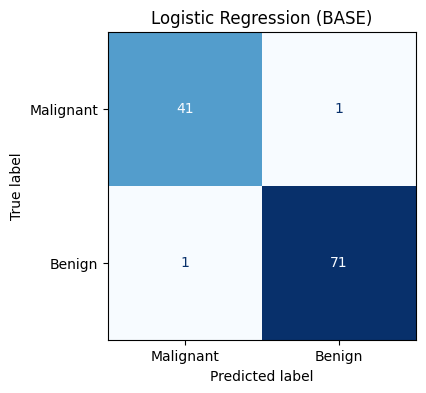

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Initialize Baseline Models
from sklearn.linear_model import LogisticRegression

# Default C=1.0 (Standard L2 Regularization)
lr_base = LogisticRegression(random_state=42)
evaluate_model(lr_base, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression (BASE)")

================ SVM (BASE) ================
Training Accuracy: 0.9824
Test Accuracy:     0.9825
Status:            Good Balance

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- Confusion Matrix (SVM (BASE)) ---


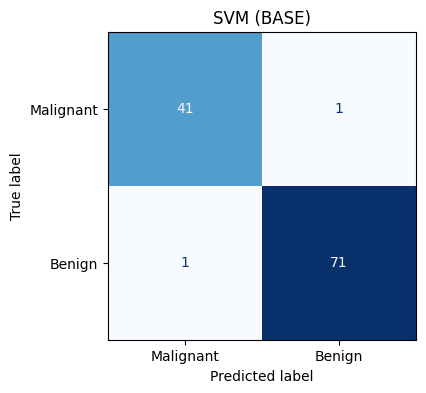

In [12]:
from sklearn.svm import SVC

# Default C=1.0, gamma='scale', kernel='rbf'
svm_base = SVC(probability=True, random_state=42)
evaluate_model(svm_base, X_train_scaled, y_train, X_test_scaled, y_test, "SVM (BASE)")

================ Decision Tree (BASE) ================
Training Accuracy: 1.0000
Test Accuracy:     0.9123
Status:            Likely OVERFITTING

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

--- Confusion Matrix (Decision Tree (BASE)) ---


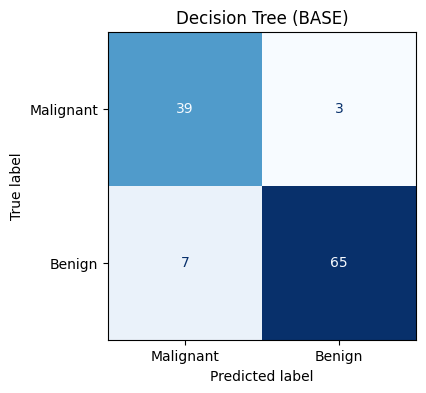

In [30]:
from sklearn.tree import DecisionTreeClassifier

# Default max_depth=None (Grows to 100% training accuracy / Overfitting)
dt_base = DecisionTreeClassifier(random_state=42)
evaluate_model(dt_base, X_train_scaled, y_train, X_test_scaled, y_test, "Decision Tree (BASE)")

### Phase 3: Manual Hyperparameter Tuning

**1. Logistic Regression** We change `C` from 1.0 to 0.01. Lower `C` means *stronger* regularization (simpler model), which might reduce overfitting but could lead to underfitting.


--- Tuned Performance (Manual) ---
================ Logistic Reg. (C=0.01) ================
Training Accuracy: 0.9560
Test Accuracy:     0.9474
Status:            Good Balance

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.97      0.88      0.93        42
      Benign       0.93      0.99      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

              precision    recall  f1-score   support

   Malignant       0.97      0.88      0.93        42
      Benign       0.93      0.99      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

--- Confusion Matrix (Logistic Reg. (C=0.01)) ---


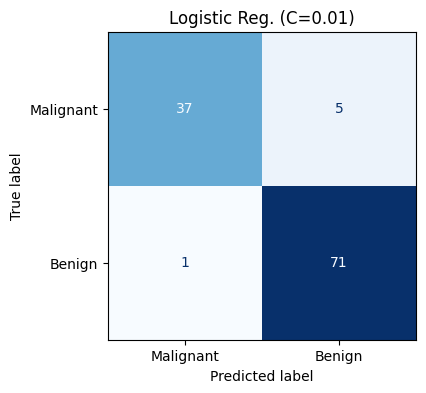

In [15]:
print("\n--- Tuned Performance (Manual) ---")

# 1. Logistic Regression: Increase Regularization (Lower C)
# Hypothesis: Might lower accuracy slightly if the linear boundary was already good,
# but makes the model more robust.
lr_tuned = LogisticRegression(C=0.01, random_state=42)
lr_tuned.fit(X_train_scaled, y_train)
evaluate_model(lr_tuned, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Reg. (C=0.01)")

================ Logistic Reg. (Underfit:C=0.0001) ================
Training Accuracy: 0.6396
Test Accuracy:     0.6579
Status:            Likely UNDERFITTING

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       1.00      0.07      0.13        42
      Benign       0.65      1.00      0.79        72

    accuracy                           0.66       114
   macro avg       0.82      0.54      0.46       114
weighted avg       0.78      0.66      0.55       114

              precision    recall  f1-score   support

   Malignant       1.00      0.07      0.13        42
      Benign       0.65      1.00      0.79        72

    accuracy                           0.66       114
   macro avg       0.82      0.54      0.46       114
weighted avg       0.78      0.66      0.55       114

--- Confusion Matrix (Logistic Reg. (Underfit:C=0.0001)) ---


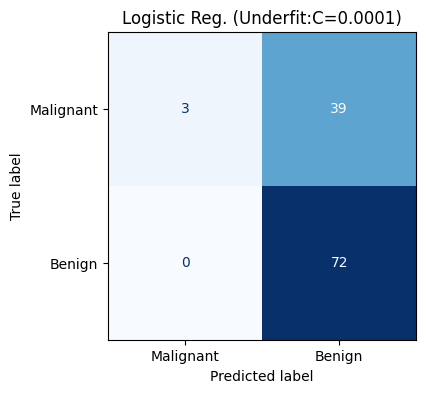

In [16]:
from sklearn.linear_model import LogisticRegression
# 1. High Regularization (Potential Underfitting)
lr_underfit = LogisticRegression(C=0.0001, random_state=42)
lr_underfit.fit(X_train_scaled, y_train)
evaluate_model(lr_underfit, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Reg. (Underfit:C=0.0001)")

**2. SVM: Harder Margin (Higher C)**

 * **Gamma:** Controls how far the influence of a single training example reaches. High Gamma = "Points must be super close to be similar" (leads to islands/overfitting).
  * **C:** Controls the penalty for misclassification. High C = "Make no mistakes on training data" (leads to overfitting).

================ SVM_(Tuned: C=100) ================
Training Accuracy: 1.0000
Test Accuracy:     0.9474
Status:            Likely OVERFITTING

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.89      0.98      0.93        42
      Benign       0.99      0.93      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114

              precision    recall  f1-score   support

   Malignant       0.89      0.98      0.93        42
      Benign       0.99      0.93      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114

--- Confusion Matrix (SVM_(Tuned: C=100)) ---


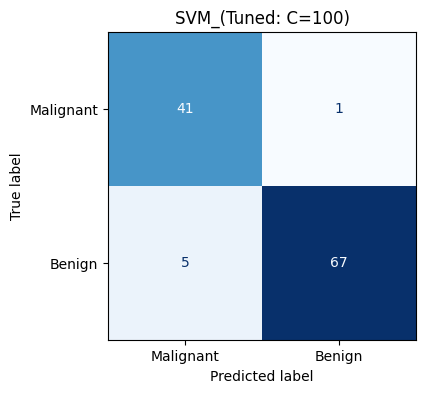

In [17]:
# Hypothesis: Tries to fit difficult points more aggressively.
svm_tuned = SVC(C=100, probability=True, random_state=42)
svm_tuned.fit(X_train_scaled, y_train)
evaluate_model(svm_tuned, X_train_scaled, y_train, X_test_scaled, y_test, "SVM_(Tuned: C=100)")

================ SVM_(Overfit: High C, High Gamma) ================
Training Accuracy: 1.0000
Test Accuracy:     0.6316
Status:            Likely OVERFITTING

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.00      0.00      0.00        42
      Benign       0.63      1.00      0.77        72

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114

              precision    recall  f1-score   support

   Malignant       0.00      0.00      0.00        42
      Benign       0.63      1.00      0.77        72

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114

--- Confusion Matrix (SVM_(Overfit: High C, High Gamma)) ---


C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


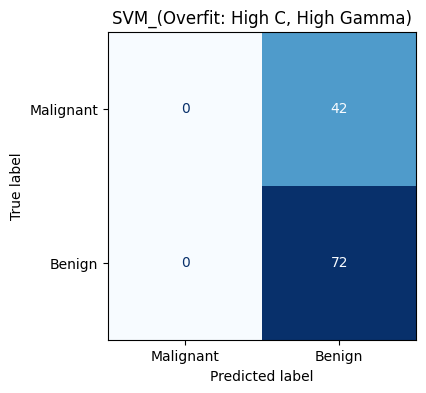

In [18]:
from sklearn.svm import SVC

# 1. High Variance Case (Overfitting)
# High C: Penalizes errors heavily.
# High Gamma: Influence is local (creates "islands" around data points).
svm_overfit = SVC(C=1000, gamma=10, probability=True, random_state=42)
svm_overfit.fit(X_train_scaled, y_train)

evaluate_model(svm_overfit, X_train_scaled, y_train, X_test_scaled, y_test, "SVM_(Overfit: High C, High Gamma)")

================ SVM_(Underfit: Low C) ================
Training Accuracy: 0.6264
Test Accuracy:     0.6316
Status:            Likely UNDERFITTING

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.00      0.00      0.00        42
      Benign       0.63      1.00      0.77        72

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114

              precision    recall  f1-score   support

   Malignant       0.00      0.00      0.00        42
      Benign       0.63      1.00      0.77        72

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114

--- Confusion Matrix (SVM_(Underfit: Low C)) ---


C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


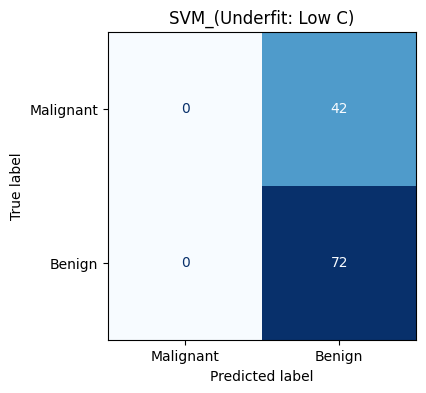

In [19]:
# 2. High Bias Case (Underfitting)
# Low C: Doesn't care much about errors.
# 'auto' gamma: sometimes too simplistic for complex data.
svm_underfit = SVC(C=0.001, gamma='auto', probability=True, random_state=42)
svm_underfit.fit(X_train_scaled, y_train)

evaluate_model(svm_underfit, X_train_scaled, y_train, X_test_scaled, y_test, "SVM_(Underfit: Low C)")

================ SVM_(SVM (Tuned) ================
Training Accuracy: 0.9824
Test Accuracy:     0.9825
Status:            Good Balance

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- Confusion Matrix (SVM_(SVM (Tuned)) ---


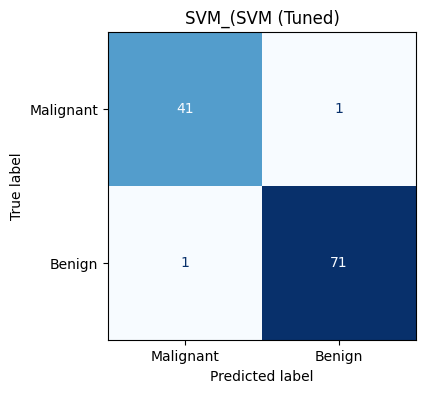

In [20]:
# 3. Tuned Case (Balanced)
# C=1.0: Default balance.
# gamma='scale': Uses 1 / (n_features * X.var()) as gamma value.
svm_tuned = SVC(C=1.0, gamma='scale', probability=True, random_state=42)
svm_tuned.fit(X_train_scaled, y_train)

evaluate_model(svm_tuned, X_train_scaled, y_train, X_test_scaled, y_test, "SVM_(SVM (Tuned)")

**3. Decision Tree:**
  * `max_depth`: Limits vertical growth.
  * `min_samples_split`: Requires a node to have X samples before it can split.
  * `min_samples_leaf`: A split is strictly forbidden if it creates a leaf with fewer than X samples.
  * `max_features`: Forces the tree to look at fewer features per split (adds randomness/robustness).

================ DT (Tuned) ================
Training Accuracy: 0.9758
Test Accuracy:     0.9386
Status:            Good Balance

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.93      0.90      0.92        42
      Benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

              precision    recall  f1-score   support

   Malignant       0.93      0.90      0.92        42
      Benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

--- Confusion Matrix (DT (Tuned)) ---


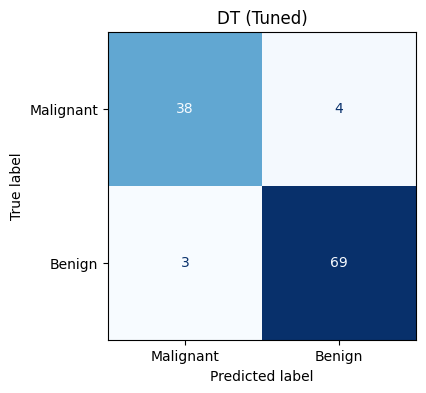

In [25]:
# Hypothesis: Reduces complexity, prevents the tree from memorizing noise.
dt_tuned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_tuned.fit(X_train_scaled, y_train)
evaluate_model(dt_tuned, X_train_scaled, y_train, X_test_scaled, y_test, "DT (Tuned)")

================ Tree (Overfit: No Limits) ================
Training Accuracy: 1.0000
Test Accuracy:     0.9123
Status:            Likely OVERFITTING

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

--- Confusion Matrix (Tree (Overfit: No Limits)) ---


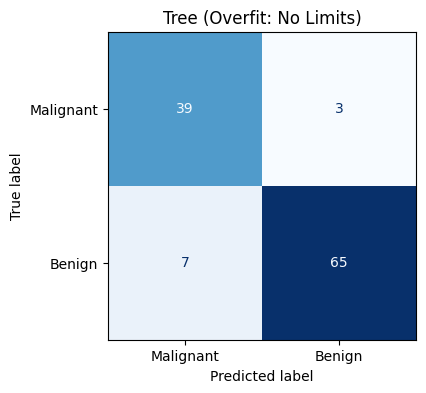

In [26]:
from sklearn.tree import DecisionTreeClassifier

# 1. Overfitting Case
# No limits. The tree memorizes the noise in the training set.
dt_overfit = DecisionTreeClassifier(
    max_depth=None, 
    min_samples_leaf=1, 
    random_state=42
)
dt_overfit.fit(X_train_scaled, y_train)
evaluate_model(dt_overfit, X_train_scaled, y_train, X_test_scaled, y_test, "Tree (Overfit: No Limits)")

================ Tree (Underfit: Depth=1) ================
Training Accuracy: 0.9231
Test Accuracy:     0.9211
Status:            Good Balance

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.92      0.86      0.89        42
      Benign       0.92      0.96      0.94        72

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

              precision    recall  f1-score   support

   Malignant       0.92      0.86      0.89        42
      Benign       0.92      0.96      0.94        72

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

--- Confusion Matrix (Tree (Underfit: Depth=1)) ---


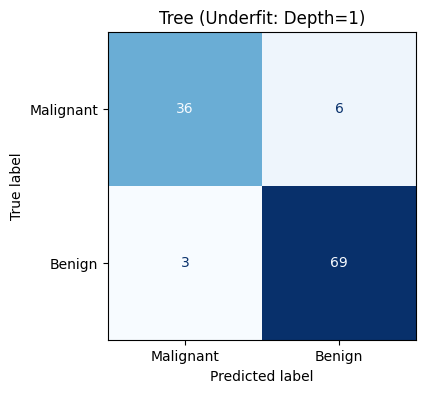

In [27]:
# 2. Underfitting Case
# Too restricted. The tree is barely allowed to make decisions.
dt_underfit = DecisionTreeClassifier(
    max_depth=1, # "Stump"
    random_state=42
)
dt_underfit.fit(X_train_scaled, y_train)
evaluate_model(dt_underfit, X_train_scaled, y_train, X_test_scaled, y_test, "Tree (Underfit: Depth=1)")

================ Tree (Tuned) ================
Training Accuracy: 0.9736
Test Accuracy:     0.9561
Status:            Good Balance

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

   Malignant       0.93      0.95      0.94        42
      Benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

              precision    recall  f1-score   support

   Malignant       0.93      0.95      0.94        42
      Benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

--- Confusion Matrix (Tree (Tuned)) ---


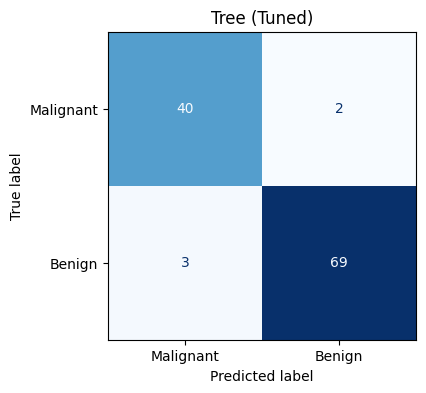

In [28]:
# 3. Tuned Case
# We force the tree to generalize.
dt_tuned = DecisionTreeClassifier(
    max_depth=10,                # Prevent deep complex rules
    min_samples_split=10,       # Don't split tiny nodes
    min_samples_leaf=5,         # Leaves must have substance
    max_features='sqrt',        # Only look at sqrt(n_features) at each split
    random_state=42
)
dt_tuned.fit(X_train_scaled, y_train)
evaluate_model(dt_tuned, X_train_scaled, y_train, X_test_scaled, y_test, "Tree (Tuned)")

### Phase 4: Visualization (Decision Boundaries)

The dataset has 30 dimensions. We cannot plot 30 dimensions on a screen. To visualize the "Decision Boundary," we must:

1.  Use **PCA (Principal Component Analysis)** to squash the data into 2 dimensions.
2.  **Retrain** the models on just these 2 dimensions (strictly for the sake of the plot).

<!-- end list -->

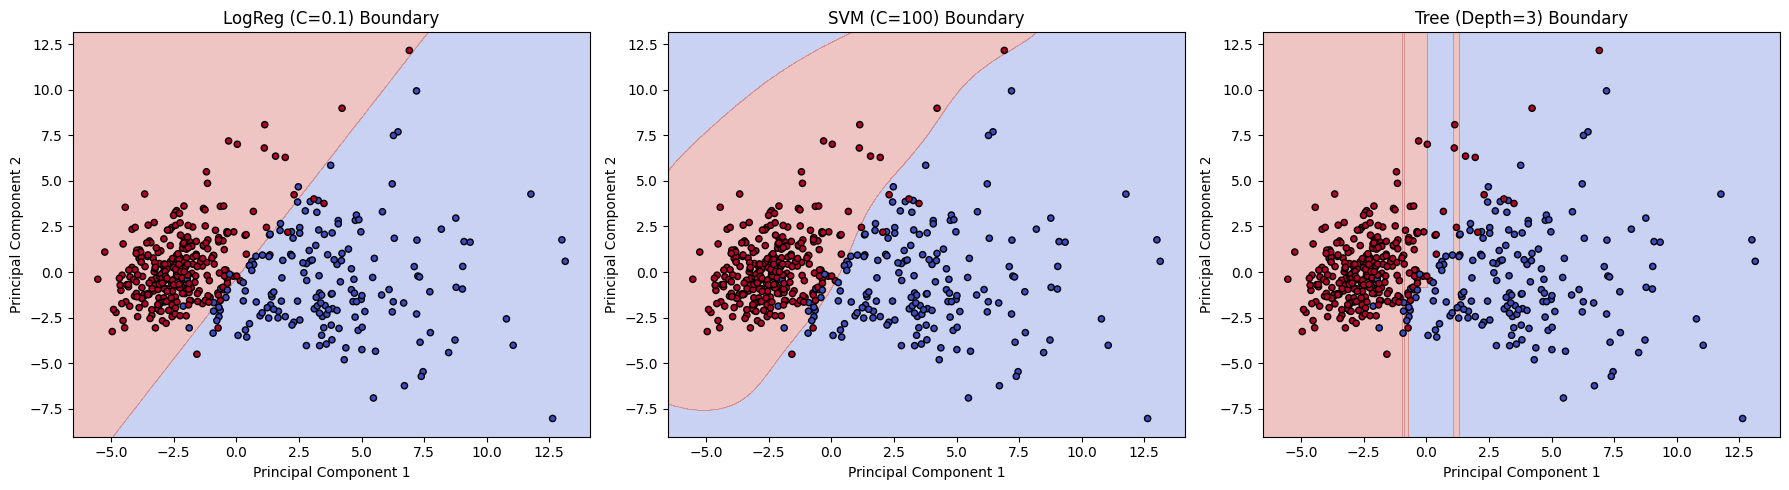

In [57]:
from sklearn.decomposition import PCA

# 1. Reduce to 2D for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# 2. Retrain models on 2D data (JUST for visualization)
# We use the 'Tuned' hyperparameters for this visual
models_viz = {
    "LogReg (C=0.1)": LogisticRegression(C=1.0, random_state=42),
    "SVM (C=100)": SVC(C=1.0, gamma='scale', probability=True, random_state=42),
    "Tree (Depth=3)": DecisionTreeClassifier(max_depth=10,                # Prevent deep complex rules
                                             min_samples_split=10,       # Don't split tiny nodes
                                             min_samples_leaf=5,         # Leaves must have substance
                                             max_features='sqrt',        # Only look at sqrt(n_features) at each split
                                             random_state=42)
}

# Setup the meshgrid
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Plot
plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(models_viz.items()):
    # Fit on 2D data
    model.fit(X_train_pca, y_train)

    # Predict on meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(1, 3, i + 1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap='coolwarm', s=20)
    plt.title(f"{name} Boundary")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

### What you will see in the plots:

1.  **Logistic Regression:** The boundary will be a perfectly **straight line**.
2.  **SVM:** The boundary will likely be **curved** (if default RBF kernel is used) or straight (if linear). Since we used default SVC (which is RBF) and high C, you will see it curving around clusters of data.
3.  **Decision Tree:** The boundary will look like **steps/boxes** (orthogonal cuts).